# Taller ingeniería de datos

El problema que se desea resolver haciendo un modelo predictivo es el siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

## Carga e identificación de problemas de los datos

Abra el archivo de datos en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargue en `Pandas` el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.

Reporte las estadísticas descriptivas de las variables numéricas y categóricas.

Identifique si el dataframe tiene datos duplicados.

Identifique si hay variables con datos nulos.

Reporte los hallazgos en un celda de texto.

##  <span style="color:green">  Taller hecho por Neithan Felipe Gomez Rivera y Daniela Higuita Agudelo

In [146]:
from pathlib import Path

import pandas as pd
    
ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = 'Telco_customer_churn.csv'

df = pd.read_csv(DATA_DIR / file_path)
df.head()
#Cuantas variables y registros hay en el dataset?

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

#### <span style="color:green"> Hay 7043 registros y 33 variables, Detecto que Total Charges debe de ser tipo float y no object, entonces lo cambio

In [148]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

#### <span style="color:green"> Reporto las estadísticas descriptivas de las variables numéricas y categóricas.

In [149]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [150]:
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [151]:
df.isnull().sum().sort_values(ascending=False).head(5)

Churn Reason     5174
Total Charges      11
CustomerID          0
Count               0
Country             0
dtype: int64

In [152]:
df[['Total Charges', 'Churn Reason']].isnull().sum()*100/df.shape[0]

Total Charges     0.156183
Churn Reason     73.463013
dtype: float64

In [153]:
#ver para todas las variables el porcentaje de valores nulos
(df.isnull().sum() * 100 / df.shape[0]).sort_values(ascending=False)

Churn Reason         73.463013
Total Charges         0.156183
CustomerID            0.000000
Count                 0.000000
Country               0.000000
Zip Code              0.000000
Lat Long              0.000000
State                 0.000000
City                  0.000000
Gender                0.000000
Senior Citizen        0.000000
Partner               0.000000
Dependents            0.000000
Tenure Months         0.000000
Phone Service         0.000000
Latitude              0.000000
Longitude             0.000000
Internet Service      0.000000
Multiple Lines        0.000000
Online Security       0.000000
Online Backup         0.000000
Streaming TV          0.000000
Streaming Movies      0.000000
Device Protection     0.000000
Tech Support          0.000000
Paperless Billing     0.000000
Contract              0.000000
Monthly Charges       0.000000
Payment Method        0.000000
Churn Label           0.000000
Churn Value           0.000000
Churn Score           0.000000
CLTV    

In [154]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


#### <span style="color:green"> Hallazgos:
- **CustomerID** es una clave primaria.
- **Count**, **Country** y **State** son variables de valor único.
- En el 73.46% de las filas no hay datos válidos de la variable **Churn Reason**.
- La información que tiene la variable **Lat Long** es la misma que contienen las variables **Latitude** y **Longitude**.


<span style="color:green"> - Total Charges era tipo object, pero todos sus datos son tipo float, asi que lo cambie

<span style="color:green"> - No hay registros duplicados

<span style="color:green"> - Solo Total Charges y Churn Reason tienen valores nulos


Descarte las variables que considere irrelevantes para su modelo (p.e. claves priamrias, variables con valores únicos, variables redundantes, entre otros).

Gestione los datos duplicados y los datos nulos.

#### <span style="color:green">Gestiono valores rebundantes como Lat Long Tambien Churn Label, ya que esta dice lo mismo que Churn Valur y variables de valor unico, tambien paso la clave primaria a index

In [155]:
df = df.set_index('CustomerID')
df = df.drop(columns=['Count', 'Country', 'State', 'Lat Long','Churn Label' ])
df.head()

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Churn Reason
CustomerID,,,,,,,,,,,,,,,,,,,,,
3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer
9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701,Moved
9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,86,5372,Moved
7892-POOKP,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003,Moved
0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,89,5340,Competitor had better devices


#### <span style="color:green">Ahora gestiono los datos nulos y duplicados (no hay duplicados) pero igual uso el drop duplicates por seguridad

In [156]:
df =  df.drop_duplicates()


In [157]:
#miro los datos nulos
df[df['Churn Value'] == 0].head()



,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Churn Reason
CustomerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Los Angeles,90001,33.973616,-118.249020,Female,No,Yes,No,1,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,27,3964,NaN
5575-GNVDE,Los Angeles,90002,33.949255,-118.246978,Male,No,No,No,34,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,61,3441,NaN
7795-CFOCW,Los Angeles,90004,34.076259,-118.310715,Male,No,No,No,45,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,66,4307,NaN
1452-KIOVK,Los Angeles,90007,34.027337,-118.285150,Male,No,No,Yes,22,Yes,...,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0,43,4459,NaN
6713-OKOMC,Los Angeles,90008,34.008293,-118.346766,Female,No,No,No,10,No,...,No,Month-to-month,No,Mailed check,29.75,301.90,0,51,2013,NaN


#### <span style="color:green">Para la variable Churn Reason al ser tantisimo porcentaje de nulos lo mejor es borrarla, y en Total Charges es mejor eliminar los datos nulos unicamente ya que es un porcentaje pequeño (no imputo en Total Charges ya que los numeros estan demasiado diferentes unos al otro, haciendolo dificil de predecir imputando, ademas de ser muy pocos los espacios nulos)

In [158]:
df = df.drop(columns=['Churn Reason'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 3668-QPYBK to 3186-AJIEK
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Zip Code           7043 non-null   int64  
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   object 
 5   Senior Citizen     7043 non-null   object 
 6   Partner            7043 non-null   object 
 7   Dependents         7043 non-null   object 
 8   Tenure Months      7043 non-null   int64  
 9   Phone Service      7043 non-null   object 
 10  Multiple Lines     7043 non-null   object 
 11  Internet Service   7043 non-null   object 
 12  Online Security    7043 non-null   object 
 13  Online Backup      7043 non-null   object 
 14  Device Protection  7043 non-null   object 
 15  Tech Support       7043 non-null   object 
 16  Streaming TV  

In [159]:
df = df.dropna(subset=['Total Charges'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 3668-QPYBK to 3186-AJIEK
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   object 
 1   Zip Code           7032 non-null   int64  
 2   Latitude           7032 non-null   float64
 3   Longitude          7032 non-null   float64
 4   Gender             7032 non-null   object 
 5   Senior Citizen     7032 non-null   object 
 6   Partner            7032 non-null   object 
 7   Dependents         7032 non-null   object 
 8   Tenure Months      7032 non-null   int64  
 9   Phone Service      7032 non-null   object 
 10  Multiple Lines     7032 non-null   object 
 11  Internet Service   7032 non-null   object 
 12  Online Security    7032 non-null   object 
 13  Online Backup      7032 non-null   object 
 14  Device Protection  7032 non-null   object 
 15  Tech Support       7032 non-null   object 
 16  Streaming TV  

## Análisis de variables categóricas

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

#### <span style="color:green">Primero miro las variables categoricas

In [160]:
df.describe(include='object').T

,count,unique,top,freq
City,7032,1129,Los Angeles,304
Gender,7032,2,Male,3549
Senior Citizen,7032,2,No,5890
Partner,7032,2,No,3639
Dependents,7032,2,No,5412
Phone Service,7032,2,Yes,6352
Multiple Lines,7032,3,No,3385
Internet Service,7032,3,Fiber optic,3096
Online Security,7032,3,No,3497
Online Backup,7032,3,No,3087


####  <span style="color:green">  Nominales:City, Senior Citizen, Gender, Partner, Phone Service, Multiple Lines, Internet Service, Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies, Paperless Billing, Payment Methor, Churn Label

####  <span style="color:green"> Ordinales: Contract 

####  <span style="color:green"> Lo primero que se ve es que la unica variable de alta cardinalidad es City

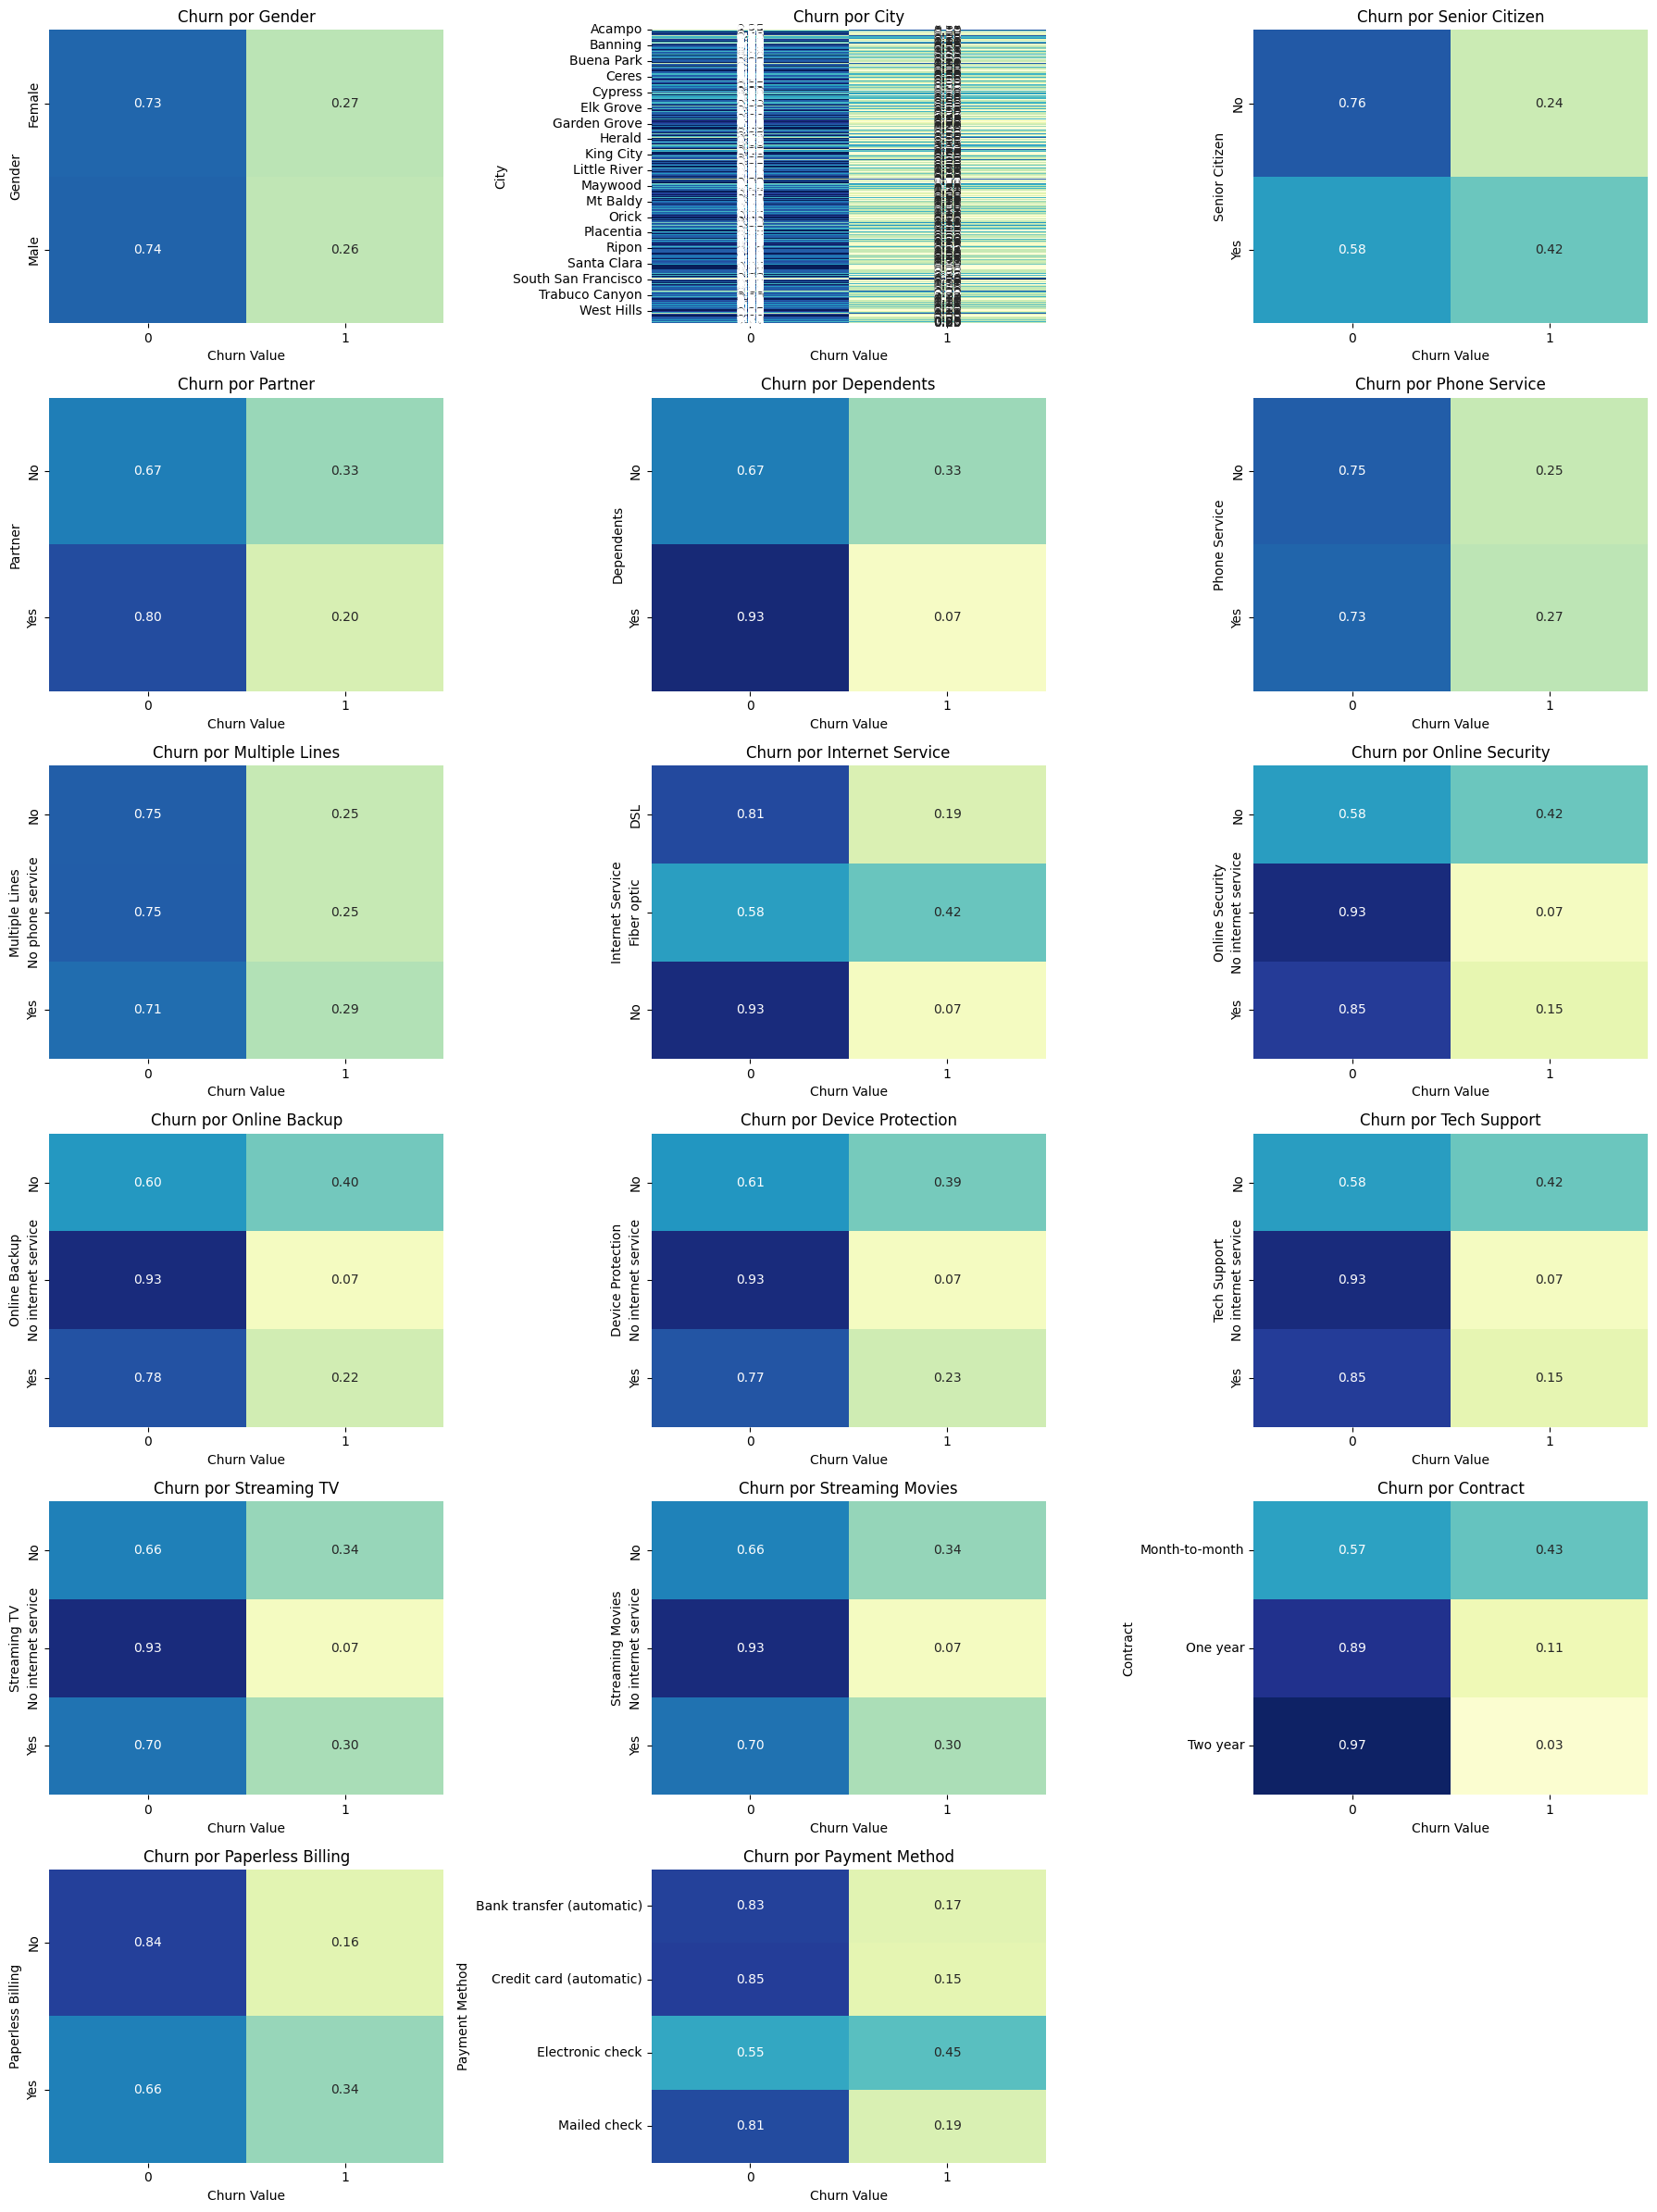

In [161]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

cols_categoricas = [
    'Gender', 'City','Senior Citizen', 'Partner', 'Dependents', 
    'Phone Service', 'Multiple Lines', 'Internet Service', 
    'Online Security', 'Online Backup', 'Device Protection', 
    'Tech Support', 'Streaming TV', 'Streaming Movies', 
    'Contract', 'Paperless Billing', 'Payment Method'
]

n_cols = 3
n_rows = math.ceil(len(cols_categoricas) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_categoricas):
    # Creamos la tabla cruzada normalizada por columnas (proporción de churn por categoría)
    tabla = pd.crosstab(df[col], df['Churn Value'], normalize='index')
    
    # Graficamos en el heatmap correspondiente
    sns.heatmap(tabla, annot=True, fmt='.2f', cmap='YlGnBu', 
                vmin=0, vmax=1, ax=axes[i], cbar=False)
    
    axes[i].set_title(f'Churn por {col}')
    axes[i].set_ylabel(col)
    axes[i].set_xlabel('Churn Value')

# Limpiar espacios vacíos si el número de variables no es múltiplo de n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

####  <span style="color:green">Eliminamos Phone Service y  Gender No se deberian de incluir segun el gráfico, así que las borramos.

In [162]:
df = df.drop(columns=['Phone Service', 'Gender'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 3668-QPYBK to 3186-AJIEK
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   object 
 1   Zip Code           7032 non-null   int64  
 2   Latitude           7032 non-null   float64
 3   Longitude          7032 non-null   float64
 4   Senior Citizen     7032 non-null   object 
 5   Partner            7032 non-null   object 
 6   Dependents         7032 non-null   object 
 7   Tenure Months      7032 non-null   int64  
 8   Multiple Lines     7032 non-null   object 
 9   Internet Service   7032 non-null   object 
 10  Online Security    7032 non-null   object 
 11  Online Backup      7032 non-null   object 
 12  Device Protection  7032 non-null   object 
 13  Tech Support       7032 non-null   object 
 14  Streaming TV       7032 non-null   object 
 15  Streaming Movies   7032 non-null   object 
 16  Contract      

## Análisis de variables cuantitativas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

####  <span style="color:green">Ninguna es Normal según el gráfico

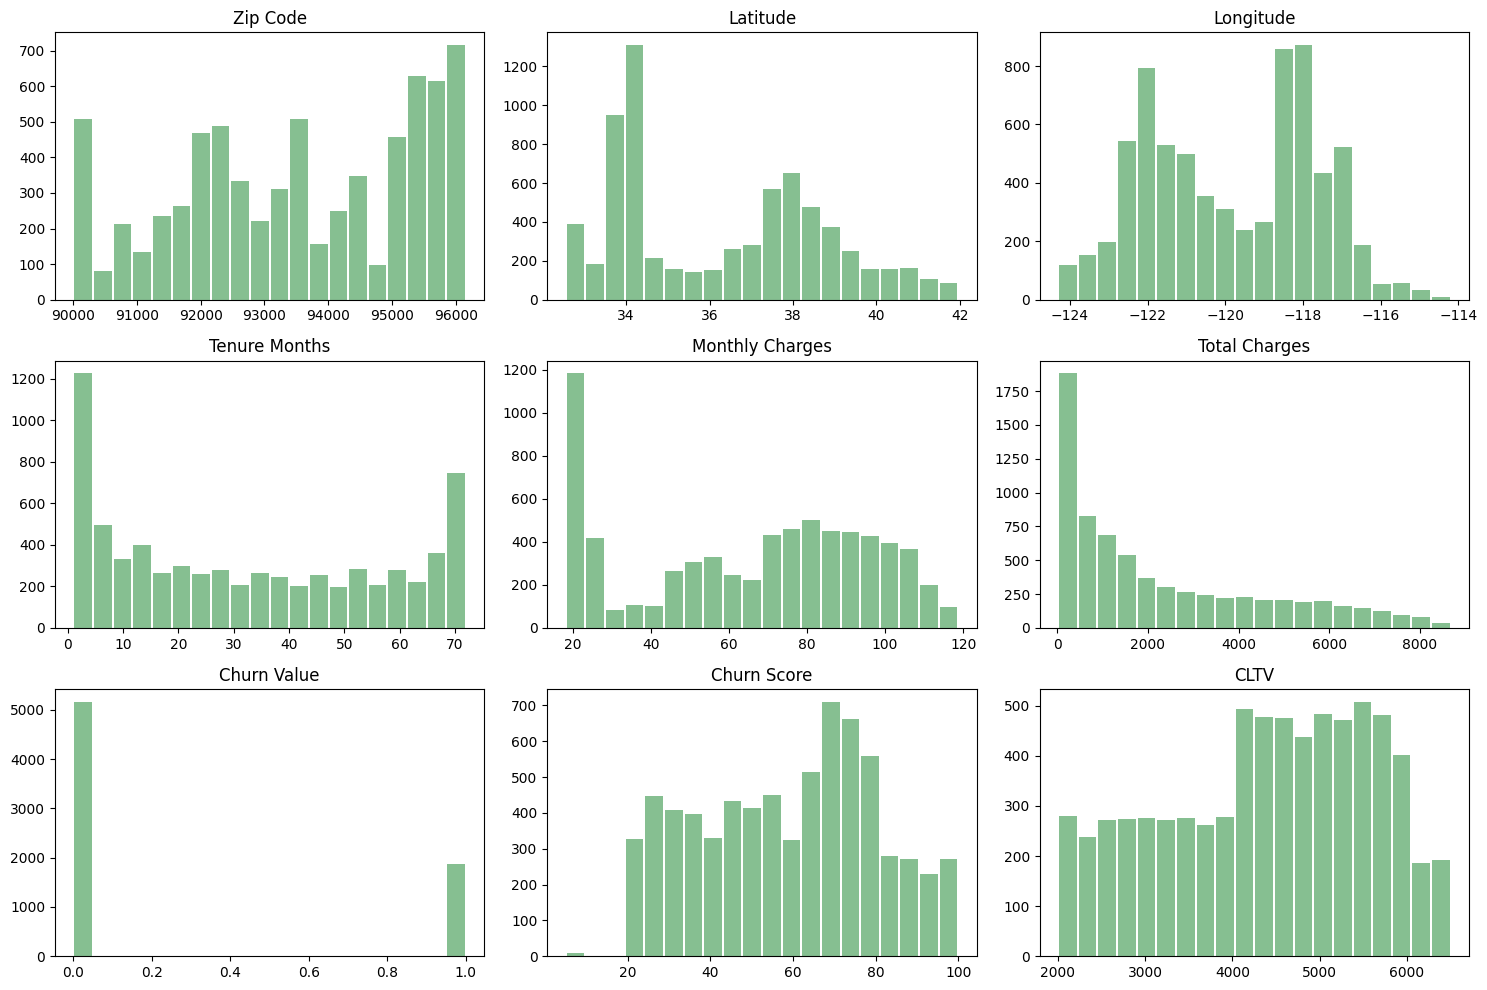

In [163]:
import matplotlib.pyplot as plt

df_num = df.select_dtypes('number')

df_num.hist(bins=20, figsize=(15, 10), grid=False, color='#86bf91', zorder=2, rwidth=0.9)

plt.tight_layout()
plt.show()

####  <span style="color:green">Variables con datos atipicos (outliners), como vemos no hay ninguna con datos atipicos mayores

Zip Code              Axes(0.125,0.712609;0.227941x0.167391)
Latitude           Axes(0.398529,0.712609;0.227941x0.167391)
Longitude          Axes(0.672059,0.712609;0.227941x0.167391)
Tenure Months         Axes(0.125,0.511739;0.227941x0.167391)
Monthly Charges    Axes(0.398529,0.511739;0.227941x0.167391)
Total Charges      Axes(0.672059,0.511739;0.227941x0.167391)
Churn Value            Axes(0.125,0.31087;0.227941x0.167391)
Churn Score         Axes(0.398529,0.31087;0.227941x0.167391)
CLTV                Axes(0.672059,0.31087;0.227941x0.167391)
dtype: object

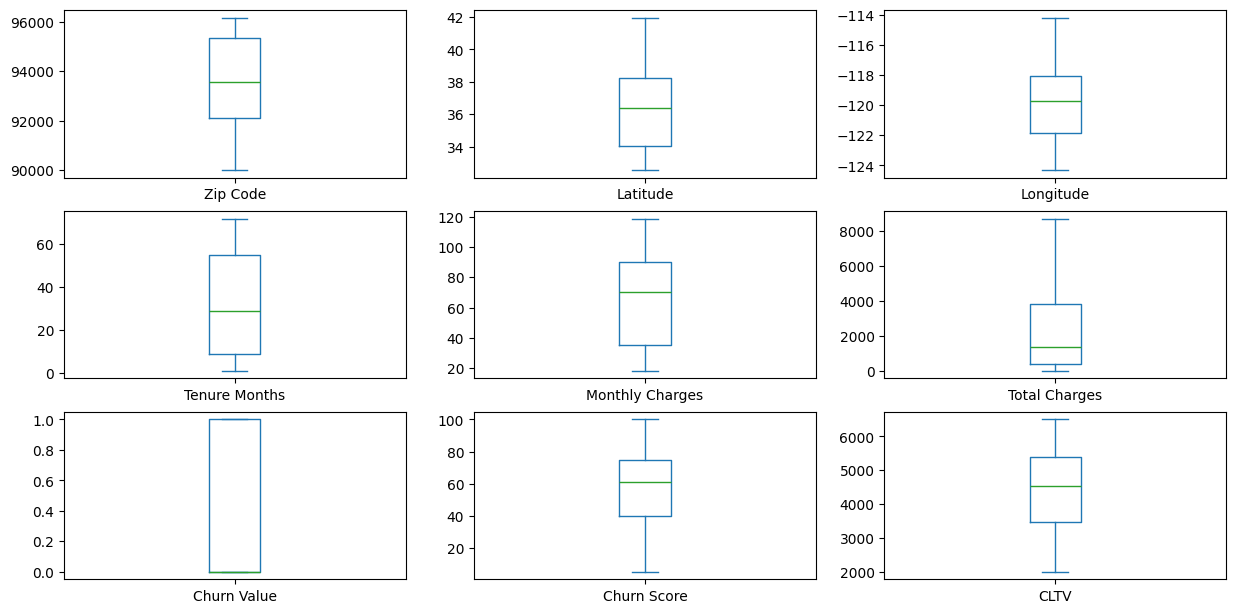

In [164]:
df_num.plot(
    kind='box',
    subplots=True,
    layout=(int(len(df_num.columns)/3)+1, 3),  # organiza en filas y 3 columnas
    figsize=(15, 10),
    grid=False
)

####  <span style="color:green">Variables que no deberían incluirse en la matriz de características, las identificamos gracias a los boxplot.

####  <span style="color:green"> Zip Code, Latitude, Longitude

--- Análisis Estadístico de Zip Code por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,93519.658726,1868.058934,90001.0,92091.0,93551.0,95346.0,96148.0
1,1869.0,93532.352595,1858.939970,90001.0,92105.0,93554.0,95358.0,96161.0


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2743/2741929407.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Value', y=var, palette='Set2')


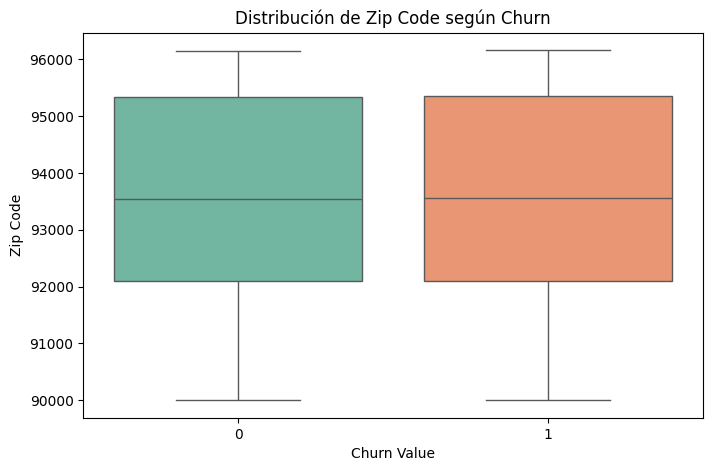

--------------------------------------------------
--- Análisis Estadístico de Latitude por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,36.288626,2.449864,32.555828,34.029109,36.414611,38.232389,41.962127
1,1869.0,36.268614,2.473911,32.555828,34.038983,36.298780,38.200231,41.962127


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2743/2741929407.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Value', y=var, palette='Set2')


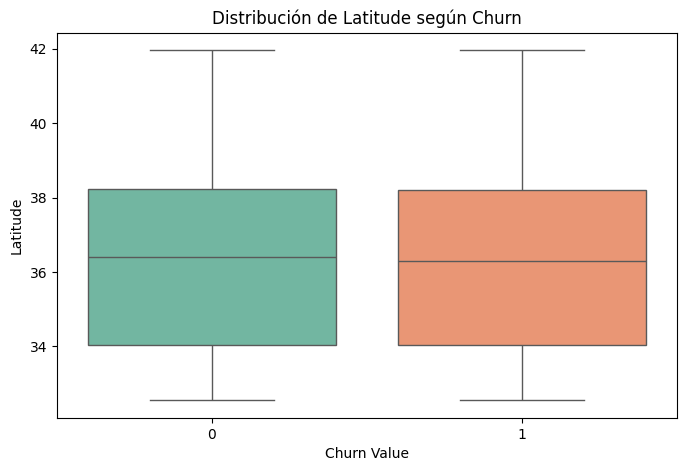

--------------------------------------------------
--- Análisis Estadístico de Longitude por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,-119.805307,2.155794,-124.301372,-121.820883,-119.739935,-118.050742,-114.192901
1,1869.0,-119.782388,2.163024,-124.301372,-121.799917,-119.711868,-118.020188,-114.192901


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2743/2741929407.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Value', y=var, palette='Set2')


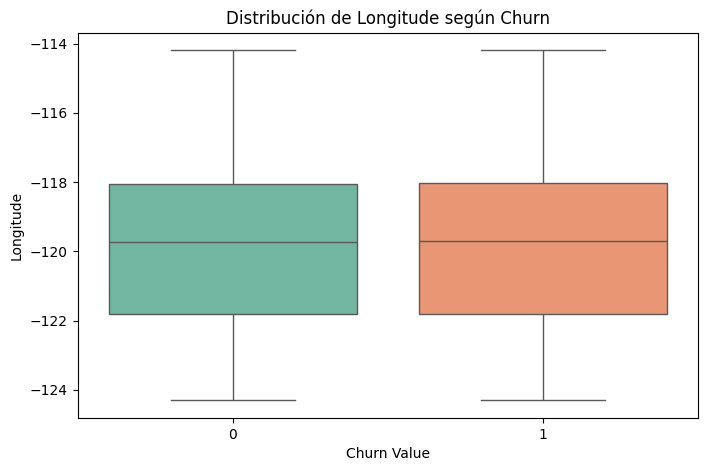

--------------------------------------------------
--- Análisis Estadístico de Tenure Months por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2743/2741929407.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Value', y=var, palette='Set2')


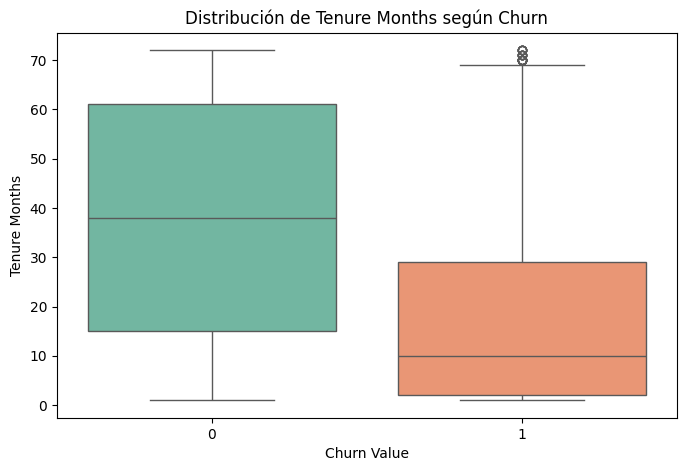

--------------------------------------------------
--- Análisis Estadístico de Monthly Charges por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2743/2741929407.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Value', y=var, palette='Set2')


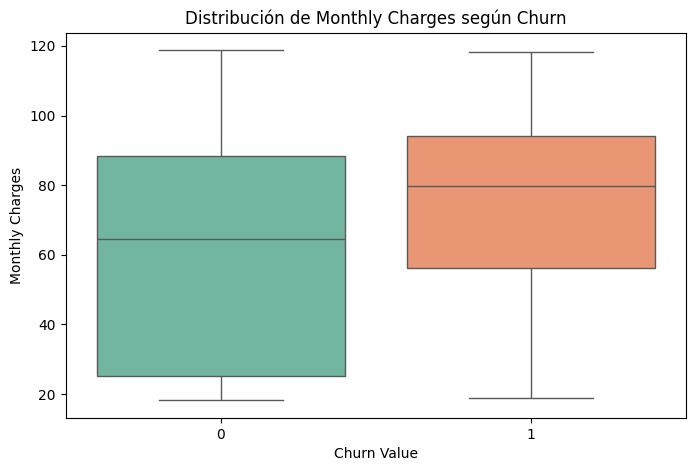

--------------------------------------------------
--- Análisis Estadístico de Total Charges por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
1,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2743/2741929407.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Value', y=var, palette='Set2')


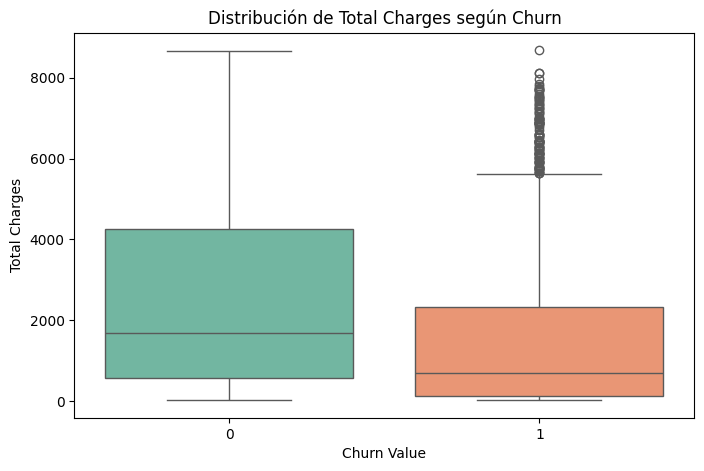

--------------------------------------------------
--- Análisis Estadístico de Churn Score por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,50.101491,17.709573,5.0,35.0,50.0,66.0,80.0
1,1869.0,82.510433,10.328570,65.0,74.0,82.0,91.0,100.0


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2743/2741929407.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Value', y=var, palette='Set2')


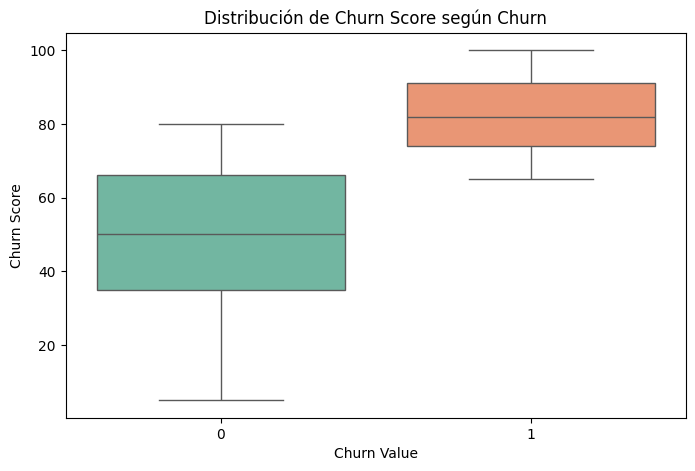

--------------------------------------------------
--- Análisis Estadístico de CLTV por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,4492.679837,1166.653300,2003.0,3649.0,4620.0,5436.0,6500.0
1,1869.0,4149.414660,1189.370707,2003.0,3101.0,4238.0,5166.0,6484.0


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2743/2741929407.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Value', y=var, palette='Set2')


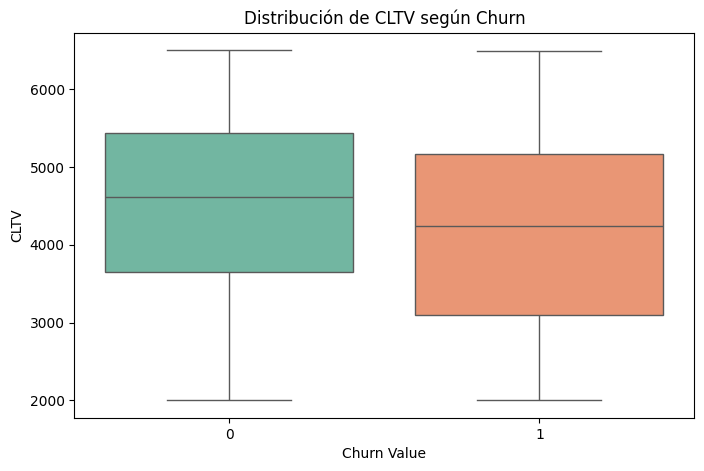

--------------------------------------------------


In [165]:
num_vars = df.select_dtypes(include=['number']).columns.tolist()
if 'Churn Value' in num_vars: num_vars.remove('Churn Value')

for var in num_vars:
    print(f"--- Análisis Estadístico de {var} por Churn Value ---")
    # El describe agrupado que mencionaste (nos da media, min, max, etc.)
    display(df.groupby('Churn Value')[var].describe())
    
    # El Boxplot adaptado (Categoría en X, Número en Y)
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Churn Value', y=var, palette='Set2')
    plt.title(f'Distribución de {var} según Churn')
    plt.show()
    print("-" * 50)

####  <span style="color:green">Eliminamos las columnas que vemos que no deben estar: Zip Code, Latitude, Longitude

In [166]:
df = df.drop(columns=['Zip Code', 'Latitude', 'Longitude'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 3668-QPYBK to 3186-AJIEK
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   object 
 1   Senior Citizen     7032 non-null   object 
 2   Partner            7032 non-null   object 
 3   Dependents         7032 non-null   object 
 4   Tenure Months      7032 non-null   int64  
 5   Multiple Lines     7032 non-null   object 
 6   Internet Service   7032 non-null   object 
 7   Online Security    7032 non-null   object 
 8   Online Backup      7032 non-null   object 
 9   Device Protection  7032 non-null   object 
 10  Tech Support       7032 non-null   object 
 11  Streaming TV       7032 non-null   object 
 12  Streaming Movies   7032 non-null   object 
 13  Contract           7032 non-null   object 
 14  Paperless Billing  7032 non-null   object 
 15  Payment Method     7032 non-null   object 
 16  Monthly Charge

## Entrenamiento del modelo

Entrene un modelo de árbol de decisión que prediga la variable **Churn Value**.

Procese las variables de acuerdo con los análisis de variables cuantitativas y categóricas hechos previamente. Este procesamiento debe empaquetarse usando `ColumnTransformer`, para que los datos de entrenamiento y prueba sean procesados por separado.

Reporte los `scores` de entrenamiento y prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del preprocesamiento.

####  <span style="color:green"> Antes de todo procesamos las variables cuantitativas y las cualitativas

In [167]:
from sklearn.model_selection import train_test_split

X = df.drop(['Churn Value'], axis=1)
y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')


Tamaño del conjunto de entrenamiento es: (4922, 20)
Tamaño del conjunto de prueba es: (2110, 20)


In [168]:
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    StandardScaler,
)

ss = StandardScaler() 
pt = PowerTransformer() 
orden = ['Month-to-month', 'One year', 'Two year'] 
ore = OrdinalEncoder(categories=[orden], dtype='int') 
ohe = OneHotEncoder(sparse_output=False, drop='if_binary') 

oheCityCardinalidadAlta = OneHotEncoder(
    sparse_output=False,
    min_frequency=100,
    handle_unknown='ignore'
)


In [169]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num_prep', ss, ['Churn Score', 'CLTV' ]), # Escalado
    ('num_prep2', pt, ['Tenure Months','Monthly Charges','Total Charges']), # Transformación
    ('cod_contract', ore, ['Contract']), # Codificación ordinal
    ('cod_all', ohe, ['Senior Citizen', 'Partner', 'Dependents', 
    'Multiple Lines', 'Internet Service', 
    'Online Security', 'Online Backup', 'Device Protection', 
    'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing', 'Payment Method']),
    ('cod_city', oheCityCardinalidadAlta, ['City'])
    ], remainder='drop') 

In [170]:
preprocessor

,transformers,"[('num_prep', ...), ('num_prep2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [171]:
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [172]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=1
    )

tree.fit(X_train_prep, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [173]:
print(f'Accuracy en el conjunto de entrenamiento: {tree.score(X_train_prep, y_train)}')
print(f'Accuracy en el conjunto de prueba: {tree.score(X_test_prep, y_test)}')

Accuracy en el conjunto de entrenamiento: 0.9250304754164974
Accuracy en el conjunto de prueba: 0.9303317535545024


In [174]:
print(preprocessor.get_feature_names_out())

['num_prep__Churn Score' 'num_prep__CLTV' 'num_prep2__Tenure Months'
 'num_prep2__Monthly Charges' 'num_prep2__Total Charges'
 'cod_contract__Contract' 'cod_all__Senior Citizen_Yes'
 'cod_all__Partner_Yes' 'cod_all__Dependents_Yes'
 'cod_all__Multiple Lines_No' 'cod_all__Multiple Lines_No phone service'
 'cod_all__Multiple Lines_Yes' 'cod_all__Internet Service_DSL'
 'cod_all__Internet Service_Fiber optic' 'cod_all__Internet Service_No'
 'cod_all__Online Security_No'
 'cod_all__Online Security_No internet service'
 'cod_all__Online Security_Yes' 'cod_all__Online Backup_No'
 'cod_all__Online Backup_No internet service' 'cod_all__Online Backup_Yes'
 'cod_all__Device Protection_No'
 'cod_all__Device Protection_No internet service'
 'cod_all__Device Protection_Yes' 'cod_all__Tech Support_No'
 'cod_all__Tech Support_No internet service' 'cod_all__Tech Support_Yes'
 'cod_all__Streaming TV_No' 'cod_all__Streaming TV_No internet service'
 'cod_all__Streaming TV_Yes' 'cod_all__Streaming Movies_N

In [175]:
print(
    'Número de características con las que fue entrenado el modelo: ', 
    preprocessor.get_feature_names_out().shape[0]
    )

Número de características con las que fue entrenado el modelo:  41


####  <span style="color:green"> Las caracteristicas con las que fue realmente entrenado el modelo fueron 41